In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [2]:
#Let's first try to modelise a Discrete Hawkes process 

def DHP(kernel,gamma,theta,law,n,alpha0):
    if kernel=="Erlang":
        alpha=np.array([gamma*np.exp(-k*theta)*k for k in range(0,n)])
    if kernel=="Exponential":
        alpha=np.array([gamma*np.exp(-k*theta) for k in range(0,n)])
    
    alpha[0]=alpha0
    X_values=np.zeros(n)
    Sn=np.zeros(n)


    if law=="Bernouilli":
        X_values[0]=np.random.binomial(1,alpha[0])
        Sn[0]=X_values[0]
        for k in range(1,n):
            X_values[k]=np.random.binomial(1,alpha[0]+np.sum(alpha[k-1:0:-1]*X_values[1:k]))
            Sn[k]=Sn[k-1]+X_values[k]
    if law=="Poisson":
        X_values[0]=np.random.poisson(alpha[0])
        Sn[0]=X_values[0]
        for k in range(1,n):
            X_values[k]=np.random.poisson(alpha[0]+np.sum(alpha[k-1:0:-1]*X_values[1:k]))
            Sn[k]=Sn[k-1]+X_values[k]


    mu=alpha0/(1+alpha[0]-np.sum(alpha)) #on veut pas d'alpha0 or np.sum(alpha) l'inclut

    if law=="Bernouilli":
        sigma_asy=mu*(1-mu)/((1+alpha[0]-np.sum(alpha))**2) #same
    if law=="Poisson":
        sigma_asy=mu/((1+alpha[0]-np.sum(alpha))**2) #same

    Sn_div_n=[Sn[k]/(k+1) for k in range(0,n)]
    sigma_div=np.array([sigma_asy/np.sqrt(k+1) for k in range(0,n)])

    upper=mu + 1.96*sigma_div
    lower=mu - 1.96*sigma_div
    n_values=np.arange(1,n+1)


    plt.plot(Sn)
    plt.title(f"Discrete Hawkes process with law : {law}, kernel : {kernel}, gamma : {gamma} and theta : {theta}")
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.show()

    plt.plot(Sn_div_n)
    plt.title("Sn/n")
    plt.axhline(mu, color="red")
    plt.fill_between(
    n_values,
    lower,
    upper,
    color="orange",
    alpha=0.2,
    label="95% CI")

    plt.plot(n_values, upper, color="orange", alpha=0.7)
    plt.plot(n_values, lower, color="orange", alpha=0.7)
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.show()

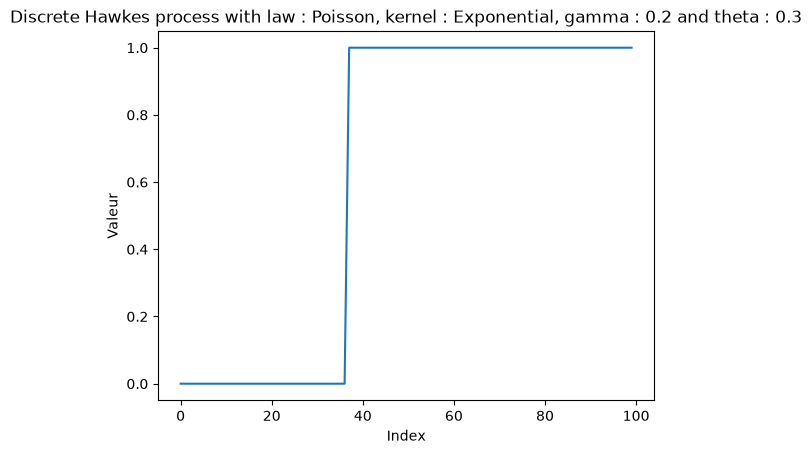

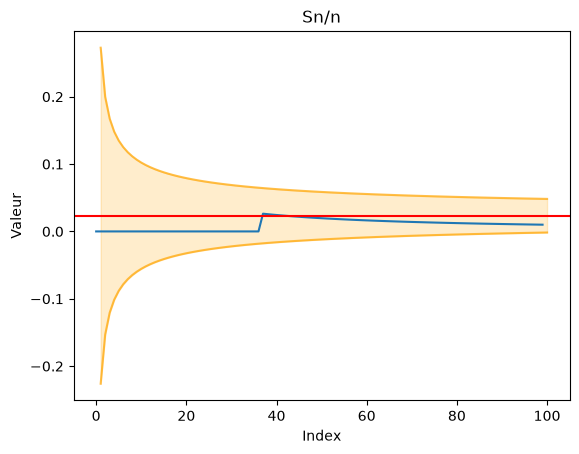

In [3]:
DHP("Exponential", 0.2, 0.3, "Poisson", 100, 0.01)

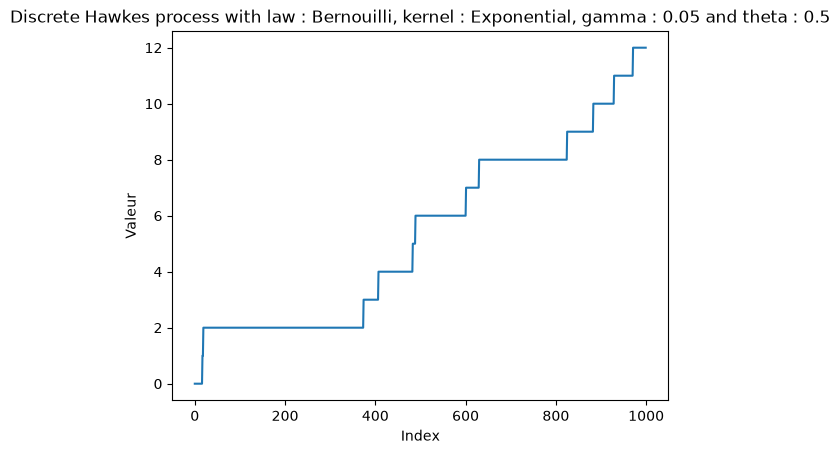

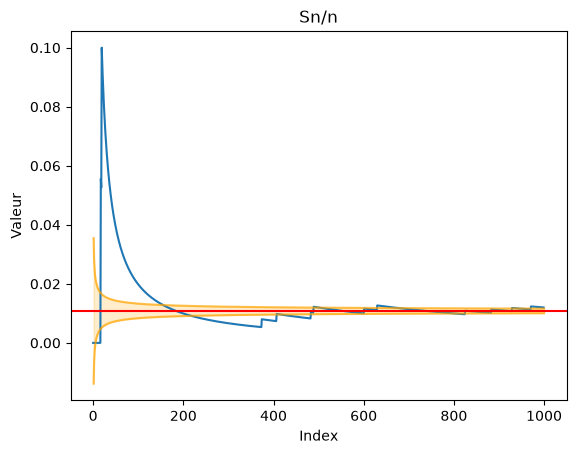

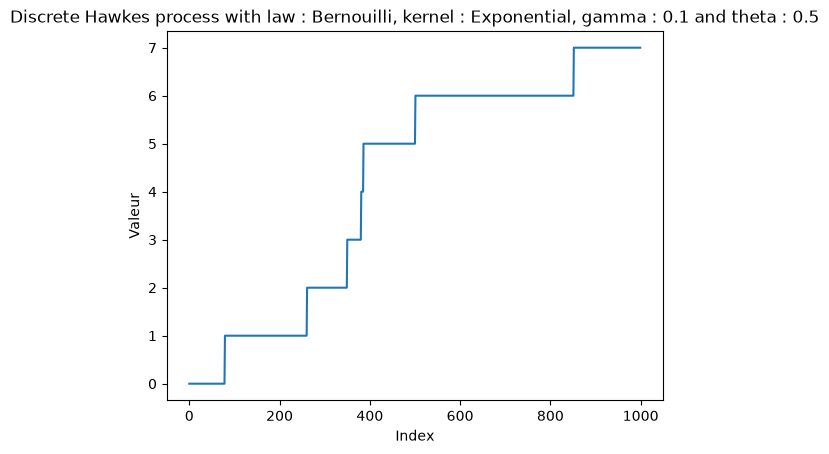

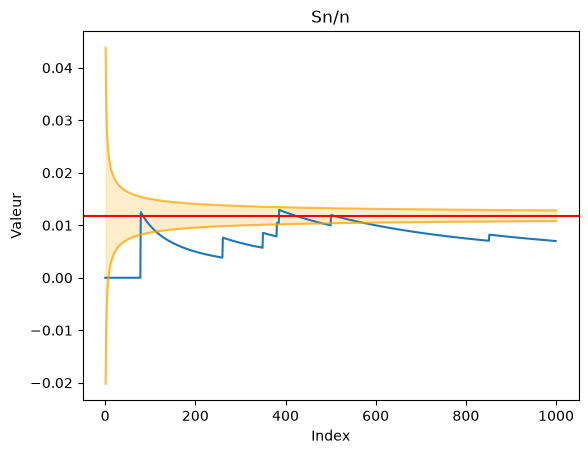

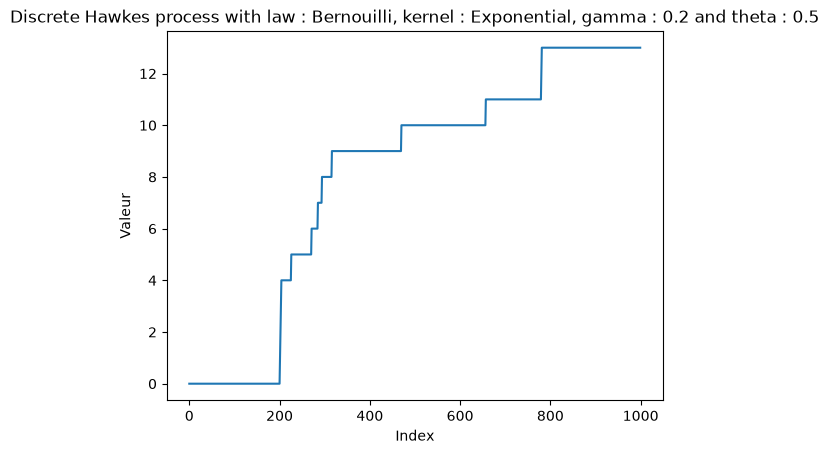

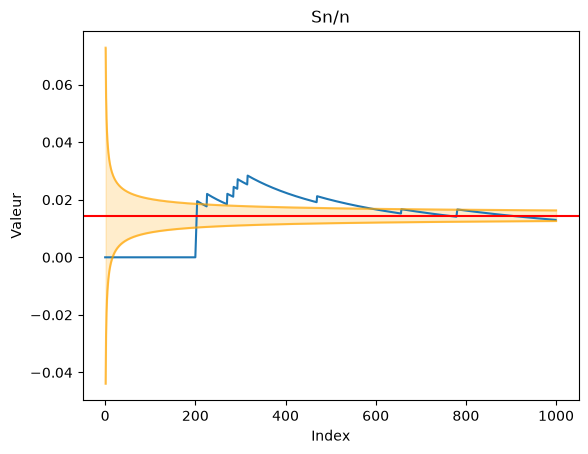

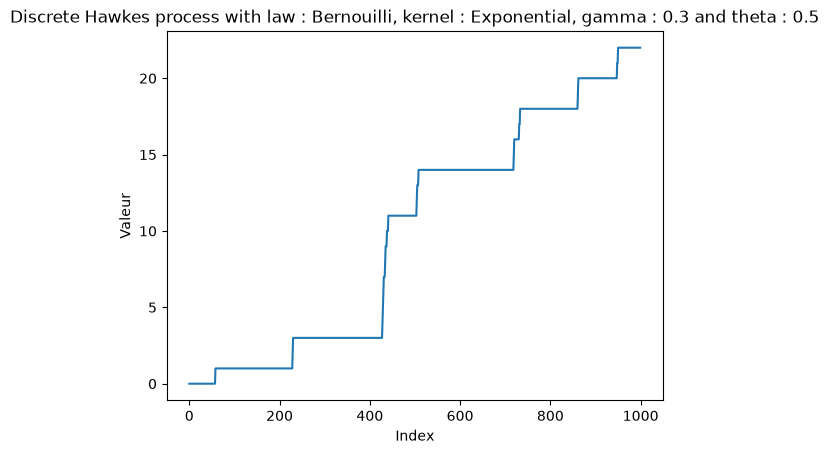

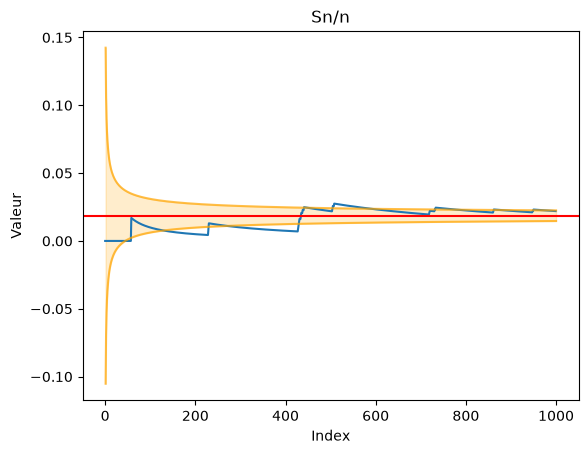

In [4]:
DHP("Exponential", 0.05, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.10, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.20, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.30, 0.5, "Bernouilli", 1000, 0.01)


In [5]:
#Let's try to code a continuous Hawkes Process
# First let's try to just inverse the distribution function
#Then we will use the Thinning d'Ogatta


#We can define it so easily and recursively just because we have an exponential kernel, which allows to just multiply each time
#For calculation, I'll add a note on how we came to such an easy loop !


def CHP(alpha0,beta,gamma,T_max):

    if gamma/beta>=1:
        raise ValueError("Attention, il est nécessaire d'avoir : γ/β < 1 afin d'assurer la condition sur la fonction d'excitation")

    #alpha 0 : intensité de fond (baseline)
    #gamma : amplitude du noyau d'excitation
    #beta : taux de décroissance

    T=0
    phi=0

    N=[]

    while True:
        u=np.random.uniform(0,1)
        F = lambda delta: 1 -(np.exp(-alpha0*delta - phi*(1-np.exp(-beta*delta))/beta)) #Fonction de répartition de Δn+1 appliqué en δ (on part de la fonction de survie)

        b = -np.log(1 - u) / alpha0 + 1e-8   # borne haute garantie (car S(b) >= 1-e^{-alpha0*b} = u) : résultat analytique (see the note) 
        #On utilise cette borne haute pour être sûr que S(b)>0 et donc que l'algo brentq (qui nécessite au moins une annulation sur l'intervalle fonctionne)

        G_delta = brentq(lambda x: F(x) - u, 0, b) #G_delta est une simulation de la variable aléatoire Δn+1 

        T=T+ G_delta #Tn+1 = Tn + Δn+1   (ici G_delta car on utilise une simulation)
        if T > T_max:
            break #Permet de sortir de la boucle dès que le T calculé dépasse le T_max fixé

        phi=phi*np.exp(-beta*G_delta) + gamma #Φn+1 = Φn * exp(-β * Δn+1) + γ

        N.append(T) #N est totalement encodé par (T1,...,Tn)


    N = np.array(N)
    
    return N



In [6]:
def CHP_plot(alpha0,beta,gamma,T_max):
    N=CHP(alpha0,beta,gamma,T_max)
    plt.step(np.concatenate([[0], N]),np.arange(len(N) + 1),where='post')
    plt.xlabel('t')
    plt.ylabel('N(t)')
    plt.title('Processus de Hawkes continu')
    plt.grid(True, alpha=0.3)
    plt.show()

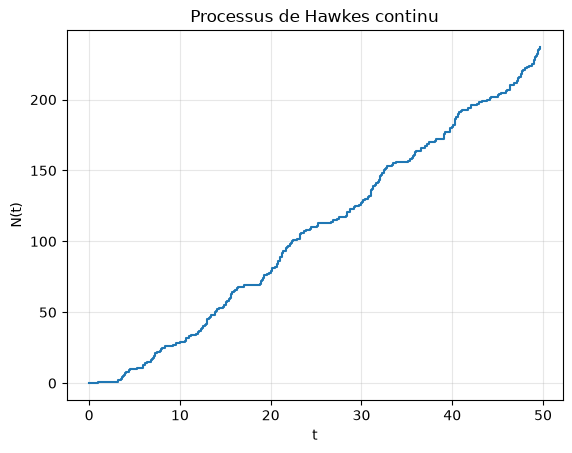

In [7]:
alpha0 = 1.0    # intensité de fond
gamma  = 0.8    # amplitude du noyau
beta   = 1.0    # taux de décroissance
T_max  = 50.0   # horizon

CHP_plot(alpha0,beta,gamma,T_max)

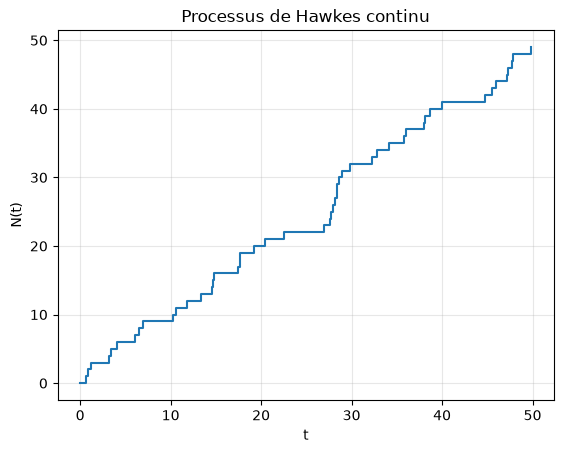

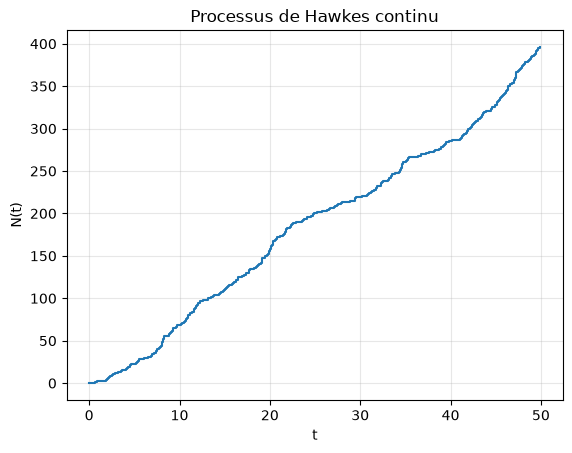

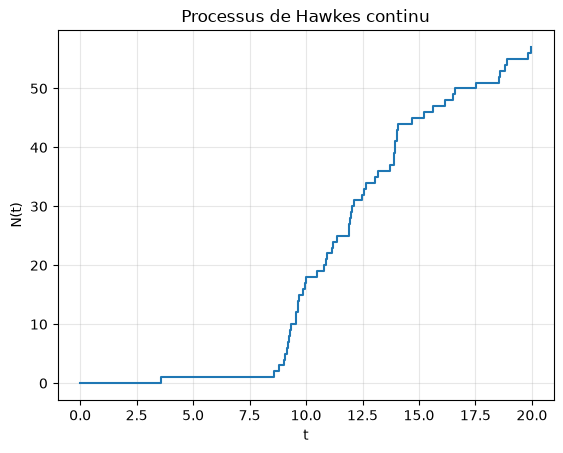

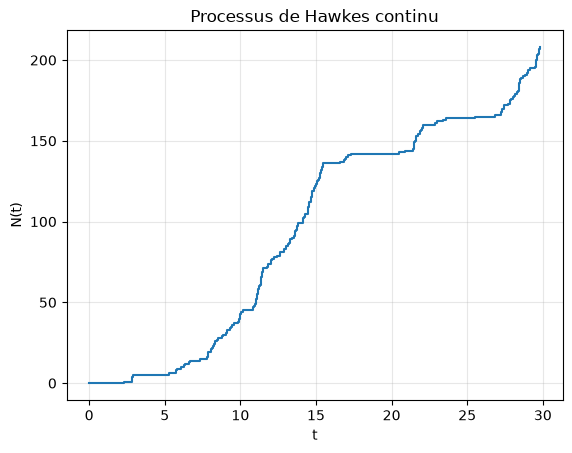

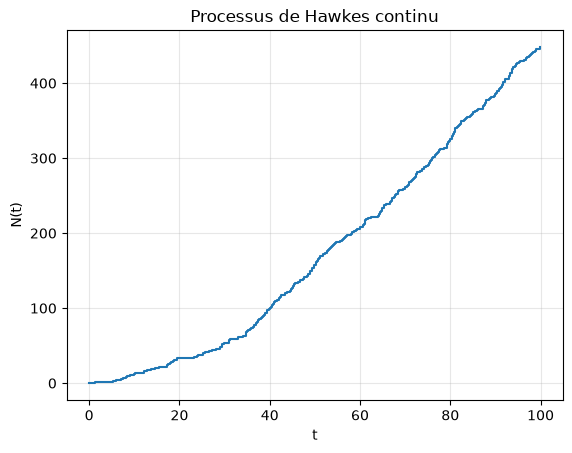

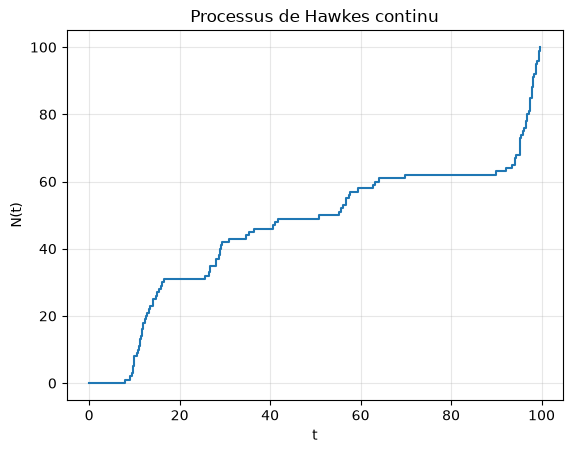

In [8]:
# alpha0 (fond)         : plancher de lambda* et taux des evts spontanes.
#                         plus grand -> moins de silences, pente de base de N(t) plus forte.
# gamma  (amplitude)    : hauteur du saut de lambda* a chaque evt.
#                         plus grand -> clustering plus intense ; vers 0 -> Poisson homogene.
# beta   (decroissance) : vitesse de retour vers alpha0, memoire ~ 1/beta.
#                         grand -> rafales compactes ; petit -> clusters etales.
# gamma/beta (branching) : regime global. vers 0 -> quasi-Poisson ;
#                          vers 1 -> cascades massives ; >= 1 -> explosion.
#                          intensite moyenne = alpha0 / (1 - gamma/beta).


CHP_plot(alpha0=0.7, beta=5, gamma=1, T_max=50)     

# 2. Clustering fort mais stable
CHP_plot(alpha0=1.0, beta=1.0, gamma=0.9, T_max=50)

# 3. Quasi-critique : grosses cascades (baisse T_max pour ne pas exploser le compte)
CHP_plot(alpha0=0.5, beta=1.0, gamma=0.95, T_max=20)

# 4. Mémoire courte : rafales très serrées puis retour rapide au fond
CHP_plot(alpha0=1.0, beta=5.0, gamma=4.0, T_max=30)

# 5. Mémoire longue : excitation qui traîne, clusters étalés
CHP_plot(alpha0=1.0, beta=0.3, gamma=0.24, T_max=100)

# 6. Fond faible, très auto-excité : longs silences puis bouffées
CHP_plot(alpha0=0.2, beta=1.0, gamma=0.85, T_max=100)

In [9]:
# On va essayer d'établir 2 choses :
# Des intervalles de confiances qui dépendent de v (la proportion de l'intervalle [0,T] que l'on observe)   
# Un intervalle de confiance qui ne dépend pas de v, donc quelque soit la proportion de l'intervalle [0,T], on devrait se situer dedans

In [10]:
# Intervalles de confiances qui dépendent de v
#De nouveau, ici on propose d'implémenter directement les résultats analytiques, voir la note.

def CHP_IC(v,alpha0,beta,gamma,T_max):
    
    mean=(v*alpha0)/(1-gamma/beta)

    sigma=np.sqrt(v*alpha0/(T_max*(1-gamma/beta)**3))

    return mean,sigma

In [11]:
def CHP_IC_plot(alpha0,beta,gamma,T_max):
    v=np.linspace(0,1,100)

    mean_v=CHP_IC(v,alpha0,beta,gamma,T_max)[0]
    sigma_v=CHP_IC(v,alpha0,beta,gamma,T_max)[1]


    lower=mean_v - 1.96 * sigma_v
    upper=mean_v + 1.96 * sigma_v
    

    # Pour la boucle : ATTENTION, ça ne veut pas dire que 95% seront entièrement dans l'intervalle de confiance
    # Notre intervalle de confiance fonctionne à v fixé, ça serait plutôt donc :
    # à v fixé, 95% des 100 points (évaluation de la trajectoire en v) se situe dans l'intervalle de confiance

    # Pour pouvoir déduire que 95% des trajectoires sont censées être situées dans notre intervalle, il faudrait qu'on ai un intervalle indépendant de v
    # Ce qui est la prochaine étape
    
    for k in range(1,100): #Pour afficher une multitude de simulations de trajectoires (indépendantes)
        N=CHP(alpha0,beta,gamma,T_max)

        seuil=T_max*v
        N_T_v=np.searchsorted(N, seuil, side='right')
    
        N_div=N_T_v/T_max # = N(Tv)/T : c'est pour celui-ci qu'on veut faire un intervalle de confiance
        plt.plot(v,N_div, alpha=0.5)

    plt.title("N(Tv)/T")
    plt.plot(v, mean_v, color="red")
    plt.fill_between(
    v,
    lower,
    upper,
    color="orange",
    alpha=0.2,
    label="95% CI")
    plt.legend()
    plt.show()
    


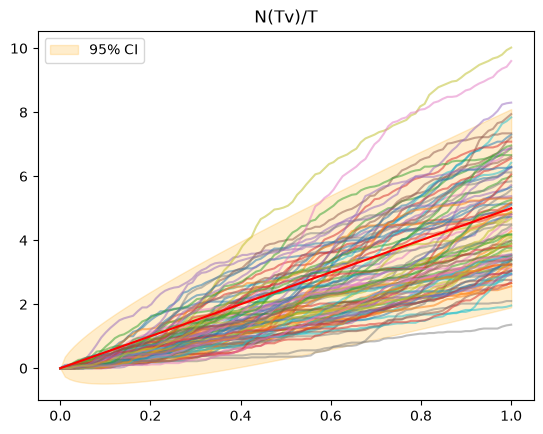

In [12]:
CHP_IC_plot(alpha0,beta,gamma,T_max)

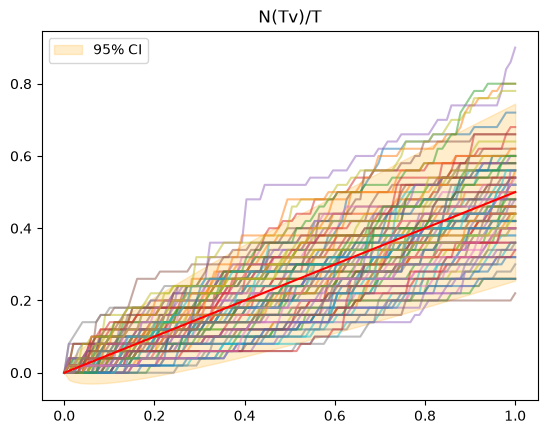

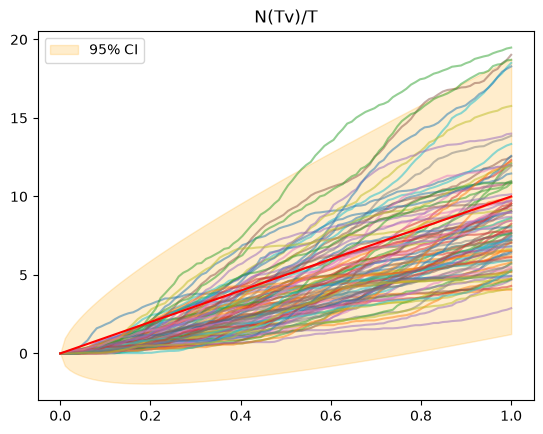

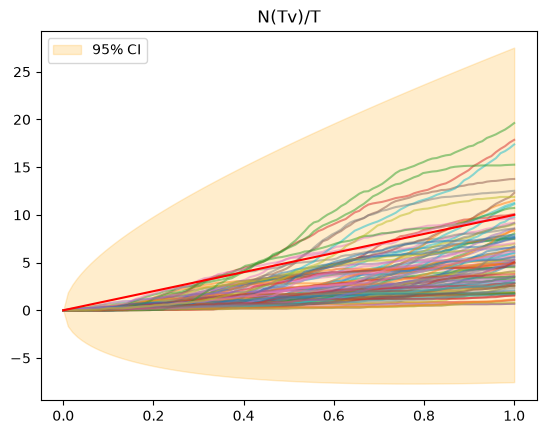

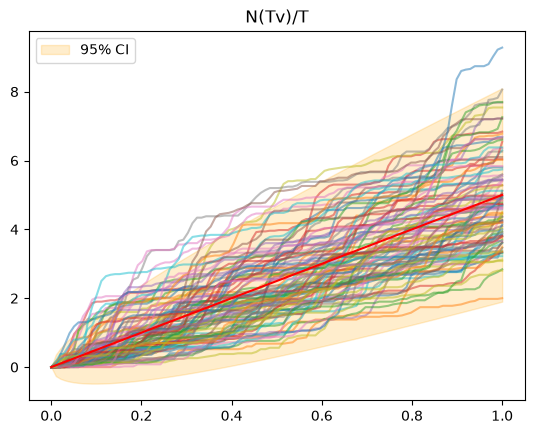

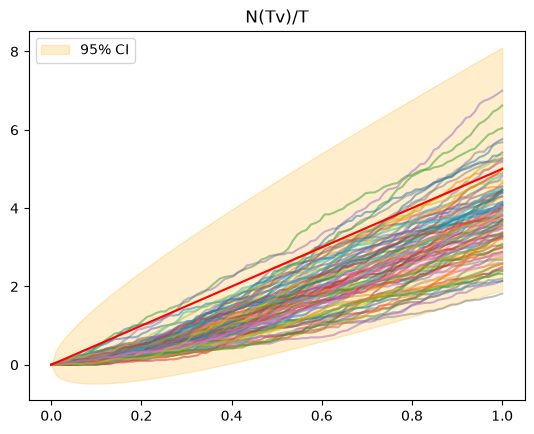

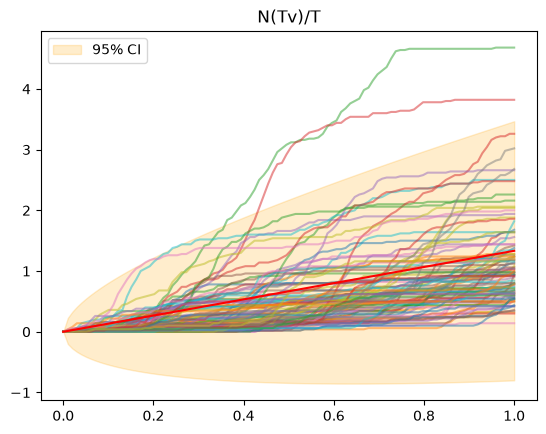

In [13]:
#Quelques plots pour voir comment notre intervalle de confiance se comporte

CHP_IC_plot(alpha0=0.4, beta=5, gamma=1, T_max=50)     

# 2. Clustering fort mais stable
CHP_IC_plot(alpha0=1.0, beta=1.0, gamma=0.9, T_max=50)

# 3. Quasi-critique : grosses cascades (baisse T_max pour ne pas exploser le compte)
CHP_IC_plot(alpha0=0.5, beta=1.0, gamma=0.95, T_max=50)

# 4. Mémoire courte : rafales très serrées puis retour rapide au fond
CHP_IC_plot(alpha0=1.0, beta=5.0, gamma=4.0, T_max=50)

# 5. Mémoire longue : excitation qui traîne, clusters étalés
CHP_IC_plot(alpha0=1.0, beta=0.3, gamma=0.24, T_max=50)

# 6. Fond faible, très auto-excité : longs silences puis bouffées
CHP_IC_plot(alpha0=0.2, beta=1.0, gamma=0.85, T_max=50)

In [14]:
time_stamp=CHP(alpha0=1.0, beta=0.3, gamma=0.24, T_max=10000)

In [15]:
#The complexity should be O(len(time_stamp)) thanks to recursion

def neg_log_likelihood(theta,time_stamp):

    alpha0, R, beta = theta #Where R is the branchement ratio (which should be 0<.<1)
    #We use the branchement ratio, because it allows to use numerical methods more robusts to constraints

    gamma = R * beta #we recalculate gamma

    k=len(time_stamp)
    A = np.zeros(k)

    first_sum=np.log(alpha0+gamma*A[0])

    # First sum
    for i in range(1,k):
        A[i]=(1+A[i-1])*np.exp(-beta*(time_stamp[i]-time_stamp[i-1]))
        first_sum+=np.log(alpha0+gamma*A[i])
    
    # Second sum

    last_time=time_stamp[k-1]   

    second_sum = np.sum((gamma / beta) * (np.exp(-beta * (last_time - time_stamp)) - 1)) #time_stamp is a vector, so everything inside np.sum is a vector


    return -(first_sum - alpha0*last_time + second_sum)

In [16]:
from scipy.optimize import minimize


theta_init = np.array([0.5, 0.5, 0.3]) 


bounds = ((1e-5, None), (1e-5, 0.999), (1e-5, None))


resultat = minimize(
    fun=neg_log_likelihood,
    x0=theta_init,
    args=(time_stamp,),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 2000, 'ftol': 1e-9}
)

print("\n--- RÉSULTATS DE L'ESTIMATION ---")
print(f"Alpha0 (baseline intensity) estimé      : {resultat.x[0]:.4f}")
print(f" Branchement Ratio (R) estimé   : {resultat.x[1]:.4f}")
print(f"Beta estimé        : {resultat.x[2]:.4f}")
print(f"-> Gamma déduit    : {(resultat.x[1] * resultat.x[2]):.4f}")
print(f"Succès             : {resultat.success}")


--- RÉSULTATS DE L'ESTIMATION ---
Alpha0 (baseline intensity) estimé      : 1.0613
 Branchement Ratio (R) estimé   : 0.7837
Beta estimé        : 0.2937
-> Gamma déduit    : 0.2302
Succès             : True


In [17]:
from scipy.stats import kstest, expon
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

def hawkes_residuals(theta, time_stamp):
    alpha0, R, beta = theta
    gamma = R * beta
    k = len(time_stamp)
    
    u = np.zeros(k - 1)
    A = np.zeros(k)
    
    #we apply the change theorem
    #We recursively calculate residuals : proof on paper
    for i in range(1, k):
        delta_t = time_stamp[i] - time_stamp[i-1]
        
        u[i-1] = alpha0 * delta_t + (gamma / beta) * (1 - np.exp(-beta * delta_t)) * (1 + A[i-1])
        
        #Update
        A[i] = (1 + A[i-1]) * np.exp(-beta * delta_t)
        
    return u

In [18]:
theta_estime = [1.0055, 0.7997, 0.2981] 

# residuals estimated
u = hawkes_residuals(theta_estime, time_stamp)

print("--- Goodness of fit ---")

# TEST 1 : Kolmogorov-Smirnov (Marginal distribution Exp(1))
# H0 : data follows an Exp(1) distribution
ks_stat, ks_pval = kstest(u, 'expon')
print(f"KS Test       -> Stat: {ks_stat:.4f} | p-value: {ks_pval:.4f}")

# TEST 2 : Ljung-Box (Linear AC until the 20th lag)
# H0 : residuals are independant (no autocorrelation)
lb_result = acorr_ljungbox(u, lags=[20], return_df=True)
lb_pval = lb_result['lb_pvalue'].iloc[0]
print(f"Ljung-Box     -> Stat: {lb_result['lb_stat'].iloc[0]:.4f} | p-value: {lb_pval:.4f}")

--- Goodness of fit ---
KS Test       -> Stat: 0.0043 | p-value: 0.3287
Ljung-Box     -> Stat: 21.0507 | p-value: 0.3942


In [19]:
import numpy as np
from scipy.stats import norm

#Test of excess of dispersion
#H0 : the variance of residuals is 1
def engle_russell_ed_test(u):

    N = len(u)
    
    #calculation of empirical dispersion (ddof = degrees of liberty = 1 to be unbiased)
    sigma2_hat = np.var(u, ddof=1)
    
    #We calculate our test statistic (that follows N(0,1) when N-> +inf)
    Z_stat = np.sqrt(N) * (sigma2_hat - 1) / np.sqrt(8)
    
    # bilateral p_value
    p_value = 2 * (1 - norm.cdf(np.abs(Z_stat)))
    
    return sigma2_hat, Z_stat, p_value



sigma2_empirique, ed_stat, ed_pval = engle_russell_ed_test(u)

print(f"empirical variance of résidus : {sigma2_empirique:.4f}")
print(f"Engle-Russell ED Test -> Stat Z: {ed_stat:.4f} | p-value: {ed_pval:.4f}")

empirical variance of résidus : 0.9937
Engle-Russell ED Test -> Stat Z: -0.4937 | p-value: 0.6215


#implémenter le test de lewis
add taht we can generate hawkes process by thinning

In [21]:
count_ks = 0
count_lb = 0
count_er = 0
count_joint = 0

# Let's try to implement the pass_rate idea of the article
numerous_timestamps = [CHP(alpha0=1.0, beta=0.3, gamma=0.24, T_max=10000) for _ in range(10)]

taille = len(numerous_timestamps)
theta_init = np.array([0.5, 0.5, 0.3]) 
bounds = ((1e-5, None), (1e-5, 0.999), (1e-5, None))

for k in range(taille):
    current_timestamps = numerous_timestamps[k]

    resultat = minimize(
        fun=neg_log_likelihood, 
        x0=theta_init,
        args=(current_timestamps,), 
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 2000, 'ftol': 1e-9}
    )

    theta_estimate = resultat.x
    
    u = hawkes_residuals(theta_estimate, current_timestamps)

    ks_stat, ks_pval = kstest(u, 'expon')

    lb_result = acorr_ljungbox(u, lags=[20], return_df=True)
    lb_pval = lb_result['lb_pvalue'].iloc[0]

    _, _, er_pval = engle_russell_ed_test(u)


    if ks_pval > 0.05:
        count_ks += 1

    if lb_pval > 0.05:
        count_lb += 1

    if er_pval > 0.05:
        count_er += 1

    if ks_pval > 0.05 and lb_pval > 0.05 and er_pval > 0.05:
        count_joint += 1

print("\n--- RÉSULTATS DES PASS RATES (sur 50 simulations) ---")
print(f"Pass Rate KS : {(count_ks / taille) * 100:.2f}%")
print(f"Pass Rate LB : {(count_lb / taille) * 100:.2f}%")
print(f"Pass Rate ED : {(count_er / taille) * 100:.2f}%")
print(f"Pass Rate Joint (KS ∩ LB ∩ ED) : {(count_joint / taille) * 100:.2f}%")


--- RÉSULTATS DES PASS RATES (sur 50 simulations) ---
Pass Rate KS : 100.00%
Pass Rate LB : 100.00%
Pass Rate ED : 100.00%
Pass Rate Joint (KS ∩ LB ∩ ED) : 100.00%


In [ ]:
#The complexity should be O(len(time_stamp)) thanks to recursion

def neg_log_likelihood_bivariate(theta,time_stamp):
